In [ ]:
# Importación de librerías principales
import numpy as np                  # Operaciones numéricas y manejo de arrays
import copy                         # Copiar objetos de Python sin referencias
import matplotlib.pyplot as plt     # Gráficos y visualización
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay  # Métricas y visualización de matriz de confusión
from sklearn.datasets import make_circles, make_moons, make_blobs      # Generación de datasets sintéticos
import sklearn.linear_model         # Modelos lineales de sklearn
from sklearn.preprocessing import StandardScaler  # Normalización de datos

# (Opcional) Utilidades externas para datasets y visualización
# from planar_utils import plot_decision_boundary, sigmoid, load_planar_dataset, load_extra_datasets
# https://www.kaggle.com/code/kolisnehar/planar-utils
# https://planar-utils.readthedocs.io/_/downloads/en/latest/pdf/


# Función para graficar la frontera de decisión de un modelo
def plot_decision_boundary(model, X, y):
    # Define un rango de valores para X e Y con un poco de margen
    x_min, x_max = X[0, :].min() - 1, X[0, :].max() + 1
    y_min, y_max = X[1, :].min() - 1, X[1, :].max() + 1
    h = 0.01
    # Crea una malla de puntos con paso h
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    # Predice para cada punto de la malla
    Z = model(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    # Dibuja los contornos y los puntos de entrenamiento
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral)
    plt.ylabel('x2')
    plt.xlabel('x1')
    plt.scatter(X[0, :], X[1, :], c=y, cmap=plt.cm.Spectral)


# Función Sigmoide: transforma valores en el rango (0,1)
def sigmoid(x):
    """
    Calcula la función sigmoide de x
    Entrada: escalar o array de cualquier tamaño
    Salida: valores en el rango (0,1)
    """
    s = 1/(1+np.exp(-x))
    return s


# Genera el dataset "planar" (forma de flor) para clasificación binaria
def load_planar_dataset():
    np.random.seed(1)
    m = 400  # número total de ejemplos
    N = int(m/2)  # ejemplos por clase
    D = 2  # número de features (dimensión)
    X = np.zeros((m,D))  # matriz de datos
    Y = np.zeros((m,1), dtype='uint8')  # etiquetas (0 o 1)
    a = 4  # radio máximo de la flor

    for j in range(2):
        ix = range(N*j, N*(j+1))
        t = np.linspace(j*3.12, (j+1)*3.12, N) + np.random.randn(N)*0.2  # ángulo (theta)
        r = a*np.sin(4*t) + np.random.randn(N)*0.2  # radio (distancia al centro)
        X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
        Y[ix] = j

    X = X.T
    Y = Y.T

    return X, Y


# Genera datasets adicionales: círculos ruidosos, lunas y blobs
def load_extra_datasets():
    N = 200
    noisy_circles = make_circles(n_samples=N, factor=.5, noise=.3)
    noisy_moons = make_moons(n_samples=N, noise=.2)
    blobs = make_blobs(n_samples=N, random_state=5, n_features=2, centers=6)

    return noisy_circles, noisy_moons, blobs


The shape of X is: (2, 400)
The shape of Y is: (1, 400)
I have m = 400 training examples!


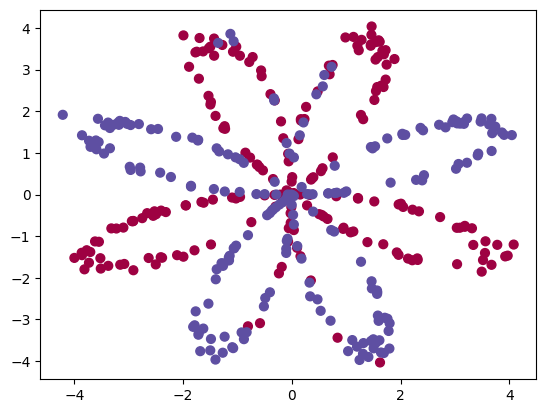

In [3]:
# Load dataset
X, Y = load_planar_dataset()

# Visualize the data:
plt.scatter(X[0, :], X[1, :], c=Y, s=40, cmap=plt.cm.Spectral);

shape_X = X.shape
shape_Y = Y.shape
m = shape_X[1]

print ('The shape of X is: ' + str(shape_X))
print ('The shape of Y is: ' + str(shape_Y))
print ('I have m = %d training examples!' % (m))


In [4]:
X

array([[ 1.20444229e+00,  1.58709904e-01,  9.52471960e-02,
         3.49178475e-01,  6.94150378e-01,  1.62065038e+00,
         1.53856225e+00,  3.63085641e-02,  4.74591109e-01,
         1.65695828e-01,  1.66446249e+00,  8.40285720e-01,
         2.61695163e-01,  2.31614896e-01,  1.58013020e+00,
         6.35509950e-03,  6.80610419e-01,  1.21400432e-01,
         1.13281261e+00,  1.61505892e+00,  1.66454441e-01,
         1.72438241e+00,  1.88667246e+00,  1.72327227e+00,
         1.54661332e+00,  9.84590400e-01,  1.45313345e+00,
         7.49043388e-01,  1.45048341e+00,  1.64287865e+00,
         1.28141487e+00,  1.59574104e+00,  1.46298294e+00,
         1.46629048e+00,  1.54348961e+00,  1.57013416e+00,
         1.22995404e+00,  1.31142345e+00, -1.99364553e+00,
         3.94564752e-01,  1.51715449e+00,  1.69169139e+00,
         1.74186686e+00, -2.91373382e+00,  7.52150898e-01,
         1.68537303e+00,  3.71160238e-01, -3.73033884e+00,
         3.52484080e-01, -1.48694206e+00, -7.45290416e-0

In [5]:
Y

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

In [ ]:
# Definimos una función para obtener las dimensiones de cada capa de la red
# X: dataset de entrada (features), Y: etiquetas (output), n_h: nodos en la capa oculta
def layer_sizes(X, Y, n_h):
    """
    Arguments:
    X -- dataset de entrada con shape (tamaño de entrada, número de ejemplos)
    Y -- etiquetas con shape (tamaño de salida, número de ejemplos)

    Returns:
    n_x -- tamaño (número de nodos) de la capa de entrada
    n_h -- tamaño de la capa oculta (definido por el usuario)
    n_y -- tamaño de la capa de salida
    """

    # número de nodos de la capa de entrada = cantidad de features
    n_x = X.shape[0]

    # número de nodos de la capa oculta (ej: 4, pero se pasa como parámetro)
    # n_h = 4   # 👉 podría fijarse directamente, pero mejor lo pasamos como argumento

    # número de nodos de la capa de salida = cantidad de clases/salidas
    n_y = Y.shape[0]

    return (n_x, n_h, n_y)


# Ejecutamos la función con 4 nodos ocultos
(n_x, n_h, n_y) = layer_sizes(X, Y, 4)

# Mostramos los tamaños de cada capa
print("The size of the input layer is: n_x = " + str(n_x))
print("The size of the hidden layer is: n_h = " + str(n_h))
print("The size of the output layer is: n_y = " + str(n_y))


The size of the input layer is: n_x = 2
The size of the hidden layer is: n_h = 4
The size of the output layer is: n_y = 1


In [ ]:
# initialize_parameters

def initialize_parameters(n_x, n_h, n_y):


    W1 = np.random.randn(n_h,n_x) * 0.01
    b1 = np.zeros((n_h, 1))
    W2 = np.random.randn(n_y, n_h) * 0.01
    b2 = np.zeros((n_y,1))

    parameters = {"W1": W1,
                  "b1": b1,
                  "W2": W2,
                  "b2": b2}

    return parameters


np.random.seed(2)
parameters = initialize_parameters(n_x, n_h, n_y)

print("W1 = " + str(parameters["W1"]))
print("b1 = " + str(parameters["b1"]))
print("W2 = " + str(parameters["W2"]))
print("b2 = " + str(parameters["b2"]))


W1 = [[-0.00416758 -0.00056267]
 [-0.02136196  0.01640271]
 [-0.01793436 -0.00841747]
 [ 0.00502881 -0.01245288]]
b1 = [[0.]
 [0.]
 [0.]
 [0.]]
W2 = [[-0.01057952 -0.00909008  0.00551454  0.02292208]]
b2 = [[0.]]


In [ ]:
# Implementamos el Forward Propagation de una red neuronal simple
def forward_propagation(X, parameters):
    """
    Argumentos:
    X -- datos de entrada, tamaño (n_x, m)  -> n_x = features, m = ejemplos
    parameters -- diccionario con los parámetros (W1, b1, W2, b2)

    Retorna:
    A2 -- salida final (probabilidades entre 0 y 1)
    cache -- diccionario con valores intermedios (Z1, A1, Z2, A2) 
             que se usarán en backpropagation
    """

    # Recuperamos los parámetros del diccionario
    W1 = parameters['W1']   # pesos capa input -> hidden
    b1 = parameters['b1']   # bias hidden
    W2 = parameters['W2']   # pesos capa hidden -> output
    b2 = parameters['b2']   # bias output

    # ---- Forward Propagation ----
    # 1) Capa oculta
    Z1 = np.dot(W1, X) + b1   # entrada lineal: W1·X + b1
    A1 = np.tanh(Z1)          # activación: tanh(Z1)

    # 2) Capa de salida
    Z2 = np.dot(W2, A1) + b2  # entrada lineal: W2·A1 + b2
    A2 = sigmoid(Z2)          # activación: sigmoide (probabilidades)

    # Verificación de dimensiones: A2 debe ser (1, número de ejemplos)
    assert(A2.shape == (1, X.shape[1]))

    # Guardamos todo en cache para reutilizarlo en backprop
    cache = {"Z1": Z1,
             "A1": A1,
             "Z2": Z2,
             "A2": A2}

    return A2, cache


# Ejecutamos el forward propagation con los datos y parámetros iniciales
A2, cache = forward_propagation(X, parameters)

# Mostramos la salida A2 (probabilidades de cada ejemplo)
print("A2 = " + str(A2))


A2 = [[0.4996522  0.50018609 0.50015804 0.50026729 0.49970121 0.5005812
  0.49971303 0.50010372 0.49973603 0.4997955  0.49969612 0.50046151
  0.49976668 0.49979938 0.49970855 0.49995075 0.49967577 0.49984969
  0.49962263 0.49966707 0.49979971 0.49978194 0.49973368 0.49969798
  0.49980326 0.49961478 0.49966447 0.4996782  0.49966797 0.49979401
  0.49964044 0.49966181 0.49963773 0.49961414 0.4996635  0.49979332
  0.49966683 0.49986857 0.50005043 0.49997581 0.49982684 0.49970772
  0.49974041 0.50003043 0.49994184 0.49980065 0.4999772  0.49995697
  0.49997984 0.50004785 0.50003125 0.49996095 0.49985395 0.49996735
  0.50000866 0.50004008 0.50001342 0.49999932 0.50003865 0.49998747
  0.5000019  0.49992616 0.50000181 0.50004517 0.49998844 0.50002838
  0.49990894 0.49989023 0.49994382 0.50001544 0.50000735 0.50002537
  0.49995746 0.49989714 0.49992011 0.49999798 0.49997054 0.49989845
  0.49990342 0.49990252 0.49992726 0.49991876 0.49989157 0.49989729
  0.49988873 0.49988984 0.49992793 0.4999063

In [9]:
A2.shape

(1, 400)

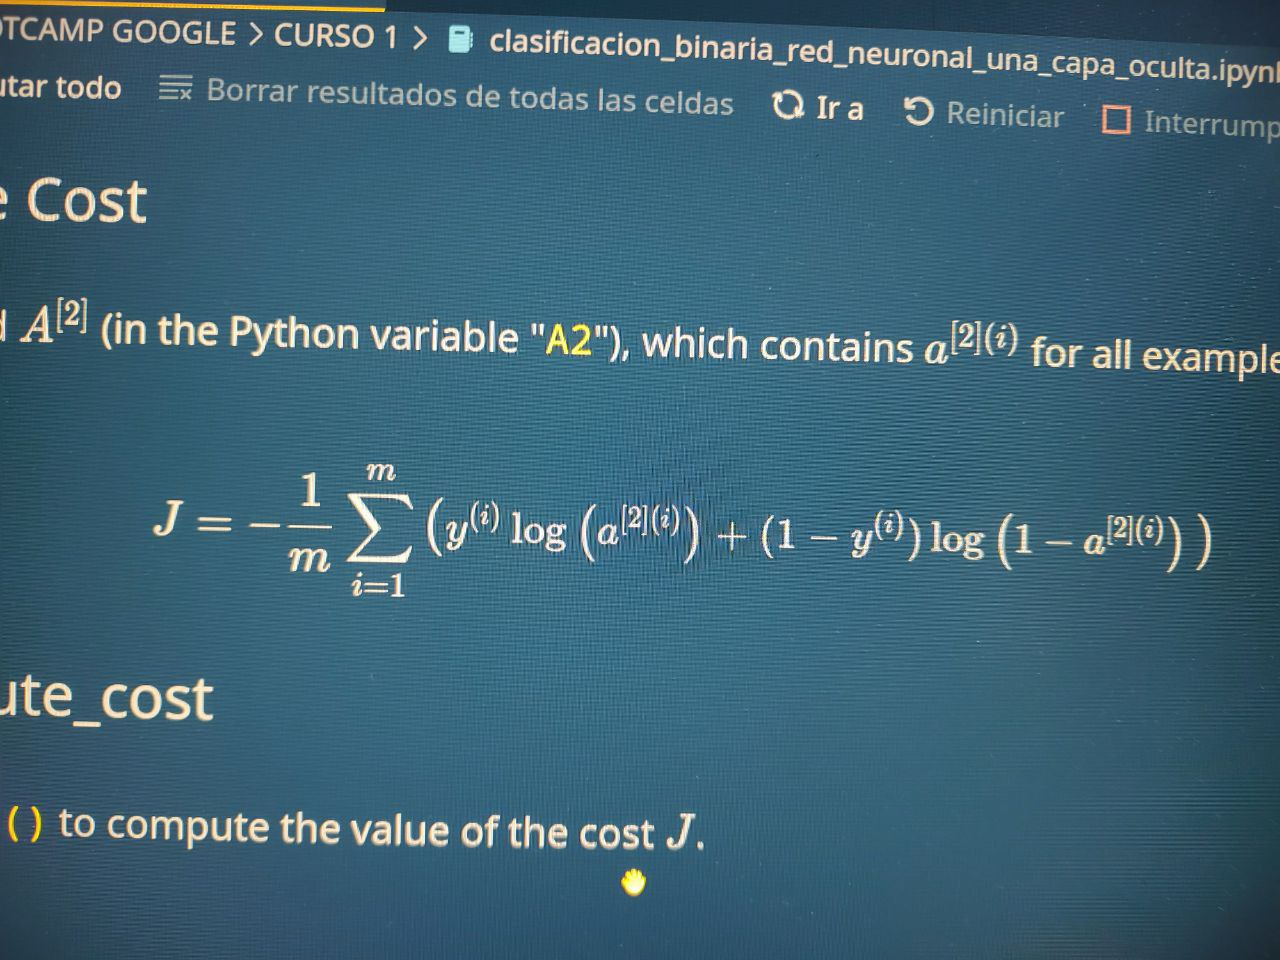

In [10]:
# https://machinelearningmastery.com/how-to-choose-loss-functions-when-training-deep-learning-neural-networks/0
# compute_cost

def compute_cost(A2, Y):
    """
    Computes the cross-entropy cost given in equation (13)

    Arguments:
    A2 -- The sigmoid output of the second activation, of shape (1, number of examples)
    Y -- "true" labels vector of shape (1, number of examples)

    Returns:
    cost -- cross-entropy cost given equation (13)

    """

    m = Y.shape[1] # number of examples

    # Compute the cross-entropy cost

    logprobs = np.multiply(np.log(A2),Y) + np.multiply(np.log(1-A2),(1-Y))
    cost = - np.sum(logprobs) / m

    cost = float(np.squeeze(cost))  # makes sure cost is the dimension we expect.
                                    # E.g., turns [[17]] into 17

    return cost


cost = compute_cost(A2, Y)
print("cost = " + str(compute_cost(A2, Y)))


cost = 0.6930480201239823


In [11]:
# backward_propagation

def backward_propagation(parameters, cache, X, Y):
    """
    Implement the backward propagation using the instructions above.

    Arguments:
    parameters -- python dictionary containing our parameters
    cache -- a dictionary containing "Z1", "A1", "Z2" and "A2".
    X -- input data of shape (2, number of examples)
    Y -- "true" labels vector of shape (1, number of examples)

    Returns:
    grads -- python dictionary containing your gradients with respect to different parameters
    """
    m = X.shape[1]

    # First, retrieve W1 and W2 from the dictionary "parameters".

    W1 = parameters['W1']
    W2 = parameters['W2']
    b1 = parameters['b1']

    # Retrieve also A1 and A2 from dictionary "cache".

    A1 = cache['A1']
    A2 = cache['A2']


    # Backward propagation: calculate dW1, db1, dW2, db2.

    dZ2 = A2 -Y
    dW2 = 1/m * np.dot(dZ2, A1.T)
    db2 = 1/m * np.sum(dZ2, axis = 1, keepdims = True)
    Z1 = np.dot(W1, X) + b1
    th_z1 = np.tanh(Z1)
    dZ1 = np.dot(W2.T, dZ2) * (1 - np.power(th_z1,2))
    dW1 = 1/m * np.dot(dZ1, X.T)
    db1 = 1/m * np.sum(dZ1, axis = 1, keepdims = True)

    grads = {"dW1": dW1,
             "db1": db1,
             "dW2": dW2,
             "db2": db2}

    return grads


grads = backward_propagation(parameters, cache, X, Y)
print ("dW1 = "+ str(grads["dW1"]))
print ("db1 = "+ str(grads["db1"]))
print ("dW2 = "+ str(grads["dW2"]))
print ("db2 = "+ str(grads["db2"]))


dW1 = [[ 0.00023606 -0.00207914]
 [ 0.0002091  -0.00178201]
 [-0.00012051  0.0010843 ]
 [-0.00051496  0.00449162]]
db1 = [[ 1.06848030e-07]
 [-9.70907252e-07]
 [-7.20012658e-08]
 [ 3.03048452e-07]]
dW2 = [[-1.75478714e-05  3.70240274e-03 -1.25686736e-03 -2.55725650e-03]]
db2 = [[-1.0892314e-05]]


In [12]:
# update_parameters

def update_parameters(parameters, grads, learning_rate = 1.2):
    """
    Updates parameters using the gradient descent update rule given above

    Arguments:
    parameters -- python dictionary containing your parameters
    grads -- python dictionary containing your gradients

    Returns:
    parameters -- python dictionary containing your updated parameters
    """
    # Retrieve a copy of each parameter from the dictionary "parameters". Use copy.deepcopy(...) for W1 and W2

    W1 = copy.deepcopy(parameters['W1'])
    b1 = parameters['b1']
    W2 = copy.deepcopy(parameters['W2'])
    b2 = parameters['b2']

    # Retrieve each gradient from the dictionary "grads"

    dW1 = grads['dW1']
    db1 = grads['db1']
    dW2 = grads['dW2']
    db2 = grads['db2']

    # Update rule for each parameter

    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1
    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2

    parameters = {"W1": W1,
                  "b1": b1,
                  "W2": W2,
                  "b2": b2}

    return parameters


parameters = update_parameters(parameters, grads)

print("W1 = " + str(parameters["W1"]))
print("b1 = " + str(parameters["b1"]))
print("W2 = " + str(parameters["W2"]))
print("b2 = " + str(parameters["b2"]))


W1 = [[-0.00445085  0.0019323 ]
 [-0.02161288  0.01854112]
 [-0.01778975 -0.00971864]
 [ 0.00564676 -0.01784282]]
b1 = [[-1.28217636e-07]
 [ 1.16508870e-06]
 [ 8.64015190e-08]
 [-3.63658142e-07]]
W2 = [[-0.01055846 -0.01353296  0.00702278  0.02599079]]
b2 = [[1.30707768e-05]]


In [13]:
# nn_model

def nn_model(X, Y, n_h, num_iterations = 10000, print_cost=False):
    """
    Arguments:
    X -- dataset of shape (2, number of examples)
    Y -- labels of shape (1, number of examples)
    n_h -- size of the hidden layer
    num_iterations -- Number of iterations in gradient descent loop
    print_cost -- if True, print the cost every 1000 iterations

    Returns:
    parameters -- parameters learnt by the model. They can then be used to predict.
    """

    np.random.seed(3)
    n_x = layer_sizes(X, Y, n_h)[0]
    n_y = layer_sizes(X, Y, n_h)[2]

    # Initialize parameters

    parameters = initialize_parameters(n_x, n_h, n_y)

    # Loop (gradient descent)

    for i in range(0, num_iterations):

        # Forward propagation. Inputs: "X, parameters". Outputs: "A2, cache".

        # Cost function. Inputs: "A2, Y". Outputs: "cost".

        # Backpropagation. Inputs: "parameters, cache, X, Y". Outputs: "grads".

        # Gradient descent parameter update. Inputs: "parameters, grads". Outputs: "parameters".

        A2, cache = forward_propagation(X, parameters)
        cost = compute_cost(A2, Y)
        grads = backward_propagation(parameters, cache, X, Y)
        parameters = update_parameters(parameters, grads)

        # Print the cost every 1000 iterations
        if print_cost and i % 1000 == 0:
            print ("Cost after iteration %i: %f" %(i, cost))

    return parameters

# predict

def predict(parameters, X):
    """
    Using the learned parameters, predicts a class for each example in X

    Arguments:
    parameters -- python dictionary containing your parameters
    X -- input data of size (n_x, m)

    Returns
    predictions -- vector of predictions of our model (red: 0 / blue: 1)
    """

    # Computes probabilities using forward propagation, and classifies to 0/1 using 0.5 as the threshold.

    A2, cache = forward_propagation(X, parameters)
    predictions = np.where(A2 > 0.5, 1, 0)

    return predictions


predictions = predict(parameters, X)
print("Predictions: " + str(predictions))


Predictions: [[0 1 1 1 0 1 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 1 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 1 1 1 1 1 1 1 0 1 1 1 1 0 0 0 1 1 1
  0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 1 1 1 0 1 1 0
  1 1 0 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0
  0 1 1 0 0 0 1 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 1 0 1 1 1 0 1 1 1 1 0 1 1 1 0 1 0 0 1 1 1 1 1 1 0 0
  1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 0 1 0 1 0
  0 1 0 1 1 0 1 0 0 1 1 0 0 0 0 1 1 0 1 0 0 1 0 0 1 0 1 0 1 0 0 1 0 1 1 0
  0 1 1 1 1 1 0 1 0 0 1 1 1 0 1 1 1 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 1 0 1 1 1 1 0 1
  1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0
  0 0 1 0]]


Cost after iteration 0: 0.693162
Cost after iteration 1000: 0.258625
Cost after iteration 2000: 0.239334
Cost after iteration 3000: 0.230802
Cost after iteration 4000: 0.225528
Cost after iteration 5000: 0.221845
Cost after iteration 6000: 0.219094
Cost after iteration 7000: 0.220648
Cost after iteration 8000: 0.219405
Cost after iteration 9000: 0.218484


Text(0.5, 1.0, 'Decision Boundary for hidden layer size 4')

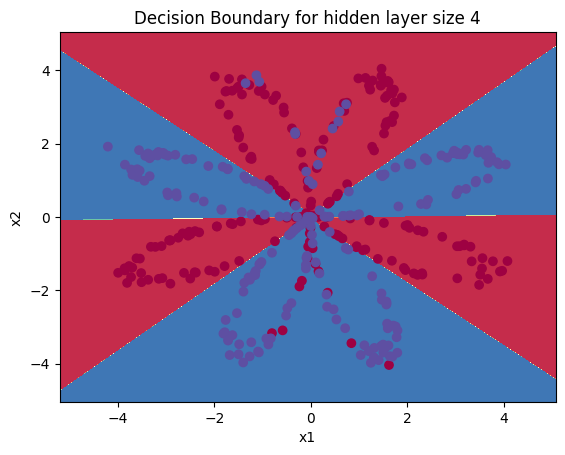

In [ ]:
# AHORA SÍ ARMAMOS NUESTRA RED NEURONAL

# Entrenamos el modelo con:
#   - X: datos de entrada
#   - Y: etiquetas (0/1)
#   - n_h = 4: número de neuronas en la capa oculta
#   - num_iterations = 10000: número de iteraciones de entrenamiento (gradiente descendente)
#   - print_cost = True: imprime el costo cada cierto número de pasos
parameters = nn_model(X, Y, n_h = 4, num_iterations = 10000, print_cost=True)


# Visualizamos la frontera de decisión del modelo entrenado
#   - lambda x: predict(parameters, x.T) -> función anónima para predecir usando los parámetros entrenados
#   - X, Y: datos reales para graficar los puntos
plot_decision_boundary(lambda x: predict(parameters, x.T), X, Y)
plt.title("Decision Boundary for hidden layer size " + str(4))


Accuracy: 90%
[[184  16]
 [ 21 179]]


<ipython-input-15-a59285046574>:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print ('Accuracy: %d' % float((np.dot(Y, predictions.T) + np.dot(1 - Y, 1 - predictions.T)) / float(Y.size) * 100) + '%')


<Figure size 640x480 with 0 Axes>

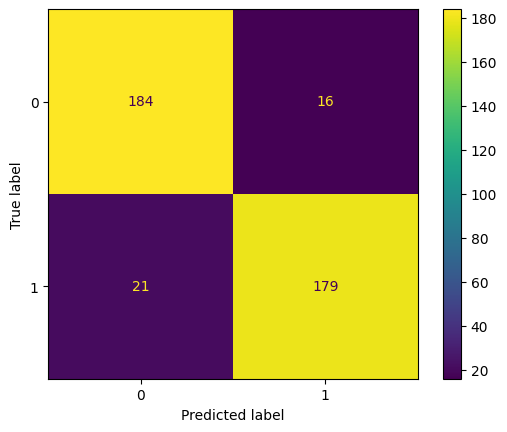

In [ ]:
# Calculamos la accuracy del modelo
# predictions = salida del modelo (0 o 1) para cada ejemplo
predictions = predict(parameters, X)

# Fórmula de accuracy:
#   (aciertos / total de ejemplos) * 100
# np.dot(Y, predictions.T) cuenta los aciertos cuando Y=1 y predice 1
# np.dot(1-Y, 1-predictions.T) cuenta los aciertos cuando Y=0 y predice 0
print('Accuracy: %d' % float(
    (np.dot(Y, predictions.T) + np.dot(1 - Y, 1 - predictions.T)) / float(Y.size) * 100
) + '%')


# Definimos una función para graficar la matriz de confusión
def matriz_confusion(y_test, y_pred):
    '''Generamos la matriz de confusión para evaluar el modelo'''

    cm = confusion_matrix(y_test, y_pred)   # calculamos la matriz
    print(cm)                               # mostramos la matriz como array
    plt.figure()
    ConfusionMatrixDisplay(cm).plot()       # dibujamos la matriz con colores
    plt.show()
    plt.close()


# Como Y y predictions son arrays columna, los aplanamos con .flatten()
# para transformarlos en vectores 1D
matriz_confusion(Y.flatten(), predictions.flatten())


# Ejemplo de interpretación (puede variar según entrenamiento):
# [[184  16]   -> 184 aciertos clase 0, 16 errores (predijo 1 cuando era 0)
#  [ 21 179]]  -> 179 aciertos c


<ipython-input-16-89d9d165bb89>:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  accuracy = float((np.dot(Y,predictions.T) + np.dot(1 - Y, 1 - predictions.T)) / float(Y.size)*100)


Accuracy for 1 hidden units: 67.5 %
Accuracy for 2 hidden units: 67.25 %
Accuracy for 3 hidden units: 90.75 %
Accuracy for 4 hidden units: 90.5 %
Accuracy for 5 hidden units: 91.25 %
Accuracy for 20 hidden units: 91.0 %
Accuracy for 50 hidden units: 90.25 %


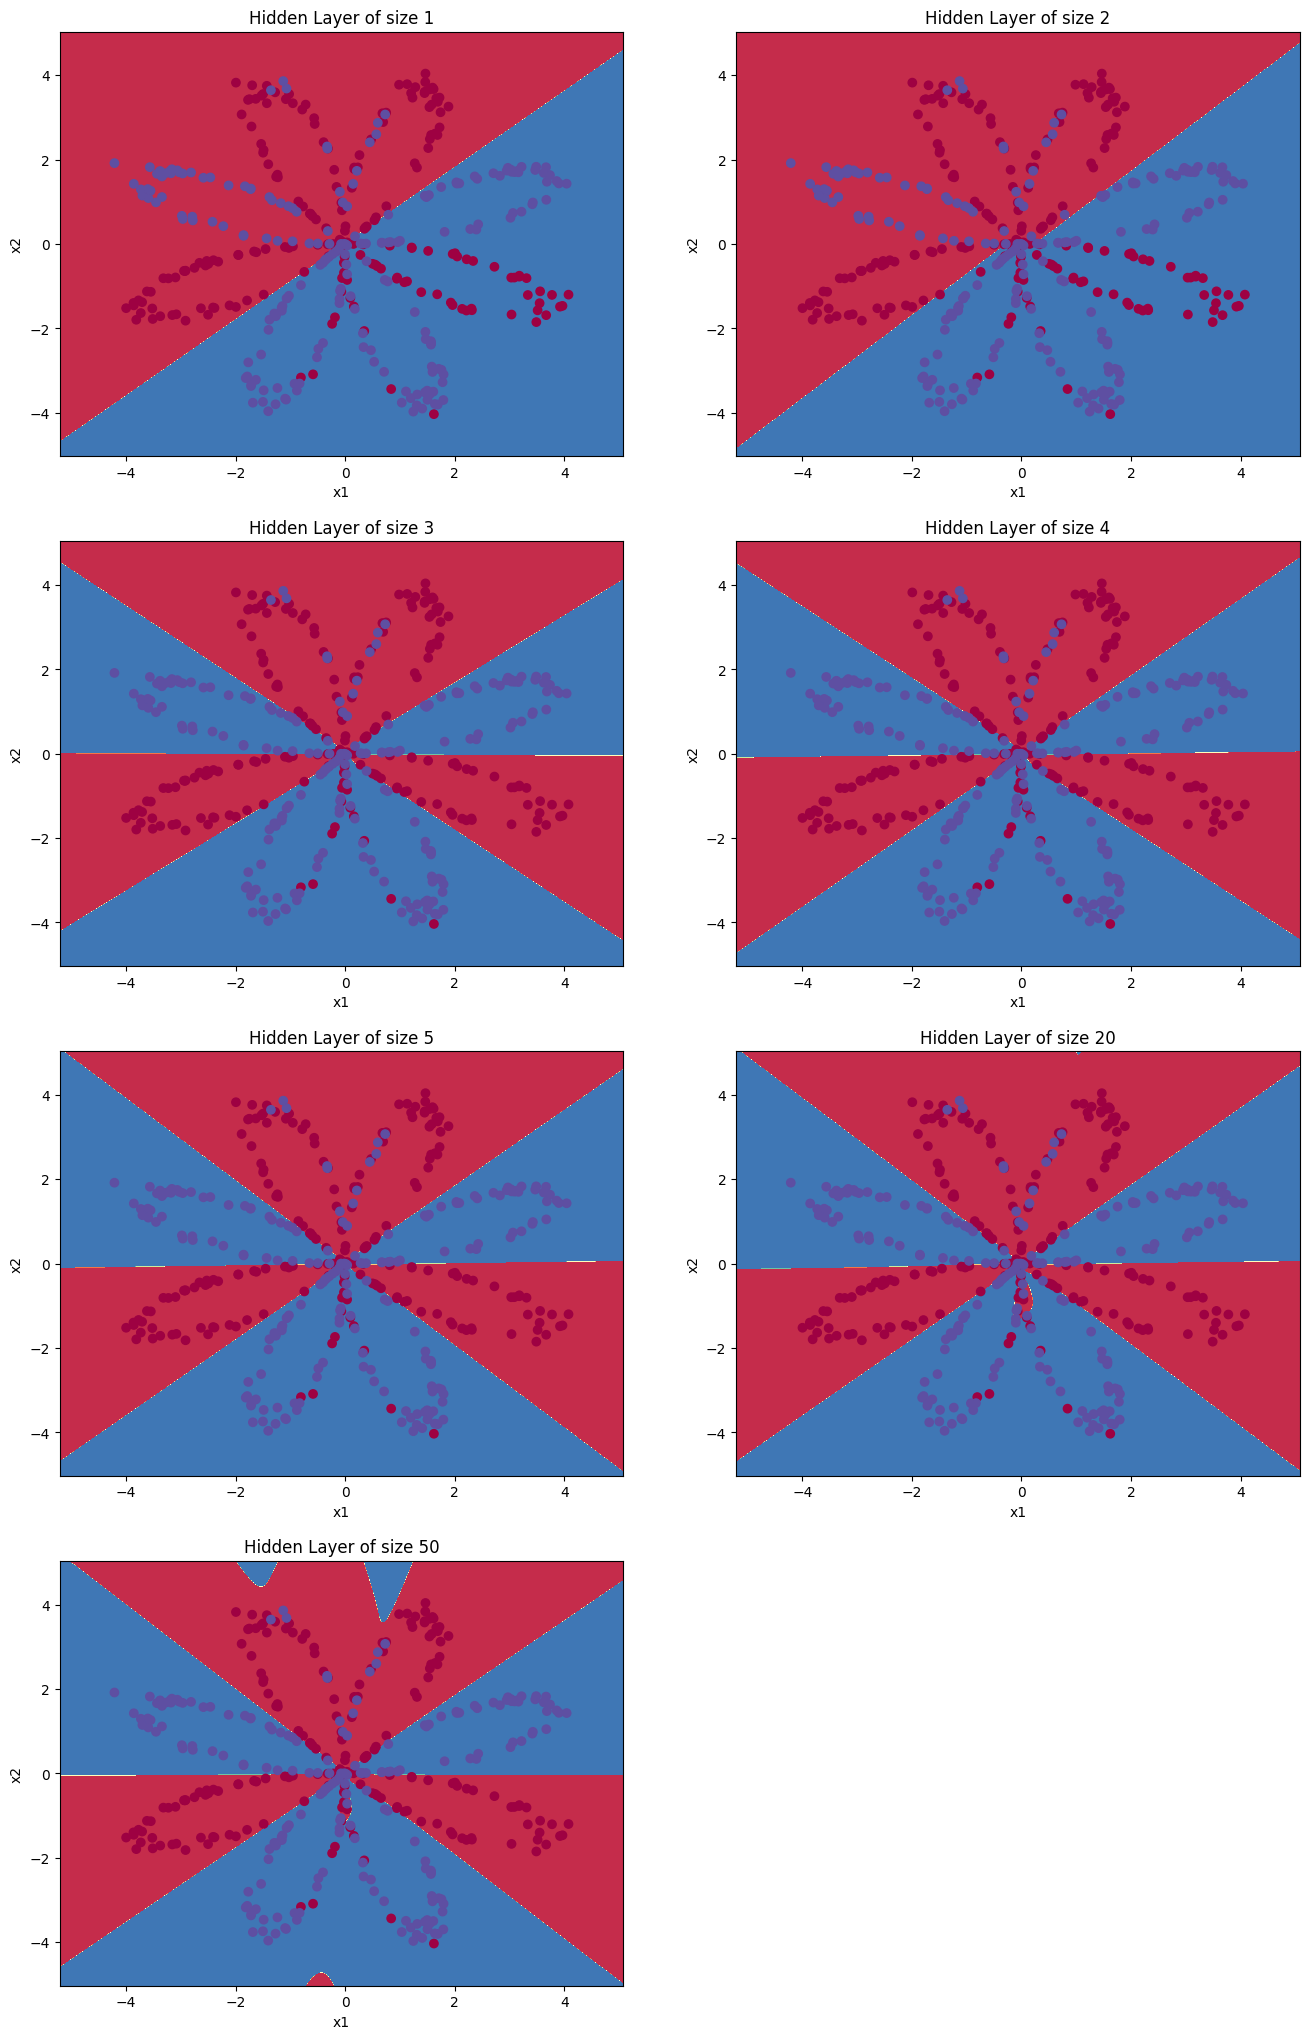

In [ ]:
#%%    CAMBIAMOS LA CANTIDAD DE UNIDADES DE LA CAPA OCULTA

# Esto puede tardar unos minutos (se entrena varias veces)
plt.figure(figsize=(16, 32))   # ajustamos el tamaño del gráfico

# Lista con diferentes tamaños de la capa oculta que queremos probar
hidden_layer_sizes = [1, 2, 3, 4, 5, 20, 50]

# Recorremos cada tamaño y entrenamos un modelo distinto
for i, n_h in enumerate(hidden_layer_sizes):
    plt.subplot(5, 2, i+1)    # posición del gráfico en una grilla (5 filas, 2 columnas)
    plt.title('Hidden Layer of size %d' % n_h)

    # Entrenamos el modelo con n_h neuronas ocultas
    parameters = nn_model(X, Y, n_h, num_iterations=5000)

    # Graficamos la frontera de decisión resultante
    plot_decision_boundary(lambda x: predict(parameters, x.T), X, Y)

    # Calculamos la accuracy del modelo entrenado
    predictions = predict(parameters, X)
    accuracy = float((np.dot(Y, predictions.T) + np.dot(1 - Y, 1 - predictions.T)) / float(Y.size) * 100)

    # Mostramos en consola el accuracy de ese tamaño de capa oculta
    print("Accuracy for {} hidden units: {} %".format(n_h, accuracy))


Dataset: noisy_circles
(200,)


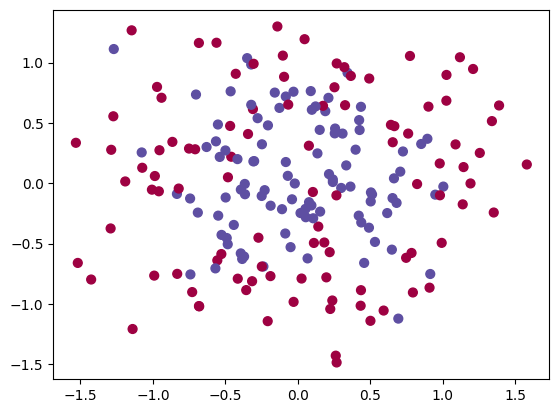

Cost after iteration 0: 0.693147
Cost after iteration 1000: 0.637718
Cost after iteration 2000: 0.634965
Cost after iteration 3000: 0.633193
Cost after iteration 4000: 0.632086
Cost after iteration 5000: 0.631311
Cost after iteration 6000: 0.630734
Cost after iteration 7000: 0.630287
Cost after iteration 8000: 0.629929
Cost after iteration 9000: 0.629637


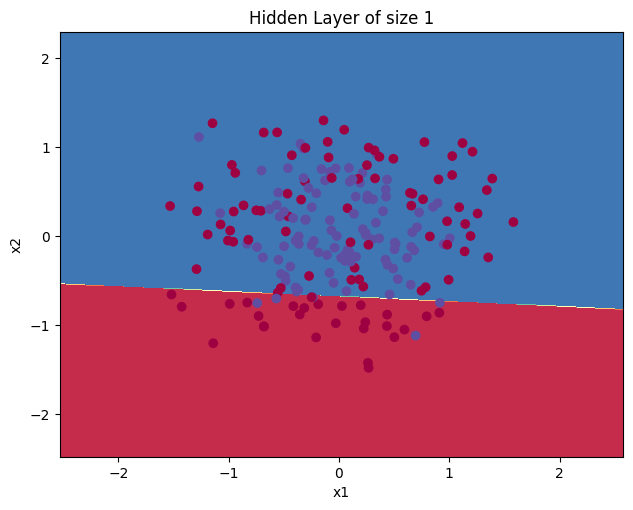

[[27 73]
 [ 5 95]]


<Figure size 640x480 with 0 Axes>

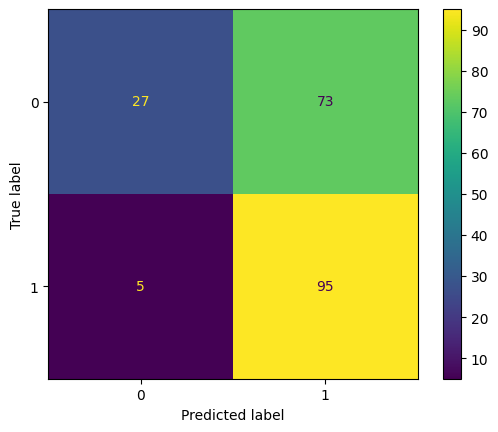

Accuracy for 1 hidden units: 61.0 %


<ipython-input-17-e9c39f94cc8a>:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  accuracy = float((np.dot(Y,predictions.T) + np.dot(1 - Y, 1 - predictions.T)) / float(Y.size)*100)


Cost after iteration 0: 0.693146
Cost after iteration 1000: 0.556972
Cost after iteration 2000: 0.553909
Cost after iteration 3000: 0.552968
Cost after iteration 4000: 0.552347
Cost after iteration 5000: 0.551869
Cost after iteration 6000: 0.551480
Cost after iteration 7000: 0.551155
Cost after iteration 8000: 0.550882
Cost after iteration 9000: 0.550649


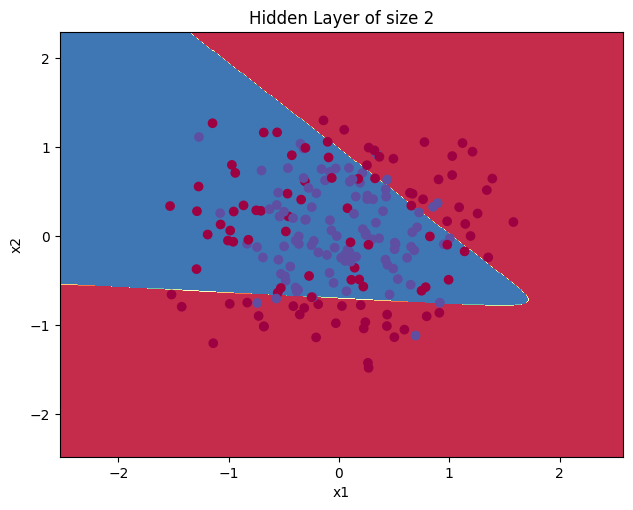

[[52 48]
 [ 8 92]]


<Figure size 640x480 with 0 Axes>

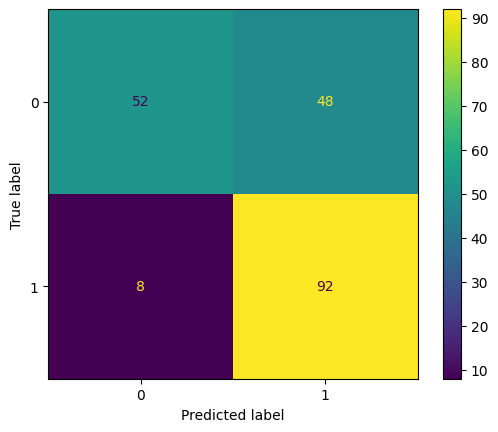

<ipython-input-17-e9c39f94cc8a>:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  accuracy = float((np.dot(Y,predictions.T) + np.dot(1 - Y, 1 - predictions.T)) / float(Y.size)*100)


Accuracy for 2 hidden units: 72.0 %
Cost after iteration 0: 0.693145
Cost after iteration 1000: 0.452968
Cost after iteration 2000: 0.452650
Cost after iteration 3000: 0.452595
Cost after iteration 4000: 0.452580
Cost after iteration 5000: 0.452574
Cost after iteration 6000: 0.452573
Cost after iteration 7000: 0.452572
Cost after iteration 8000: 0.452572
Cost after iteration 9000: 0.452572


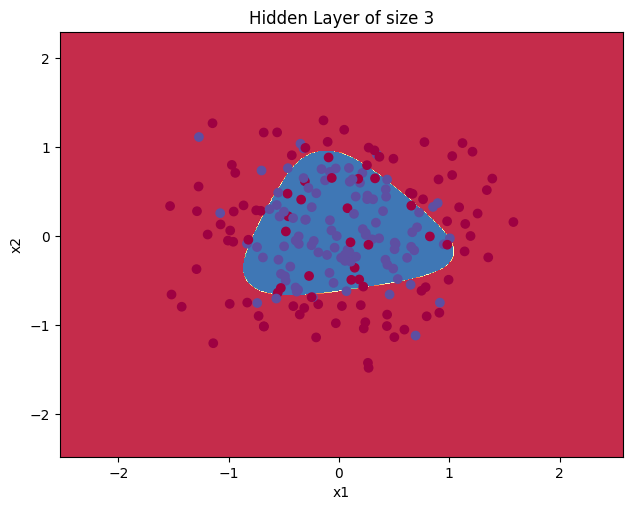

[[78 22]
 [20 80]]


<Figure size 640x480 with 0 Axes>

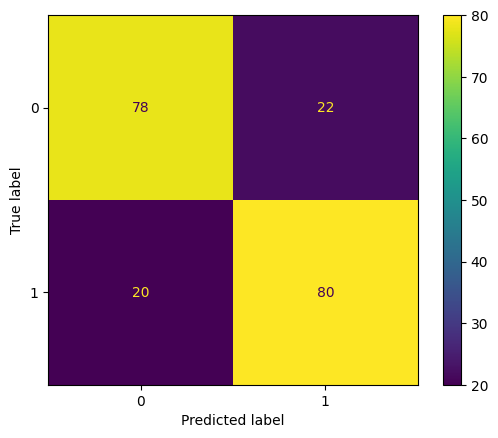

Accuracy for 3 hidden units: 79.0 %


<ipython-input-17-e9c39f94cc8a>:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  accuracy = float((np.dot(Y,predictions.T) + np.dot(1 - Y, 1 - predictions.T)) / float(Y.size)*100)


Cost after iteration 0: 0.693146
Cost after iteration 1000: 0.451125
Cost after iteration 2000: 0.447725
Cost after iteration 3000: 0.446440
Cost after iteration 4000: 0.448331
Cost after iteration 5000: 0.448100
Cost after iteration 6000: 0.447719
Cost after iteration 7000: 0.447083
Cost after iteration 8000: 0.446550
Cost after iteration 9000: 0.446136


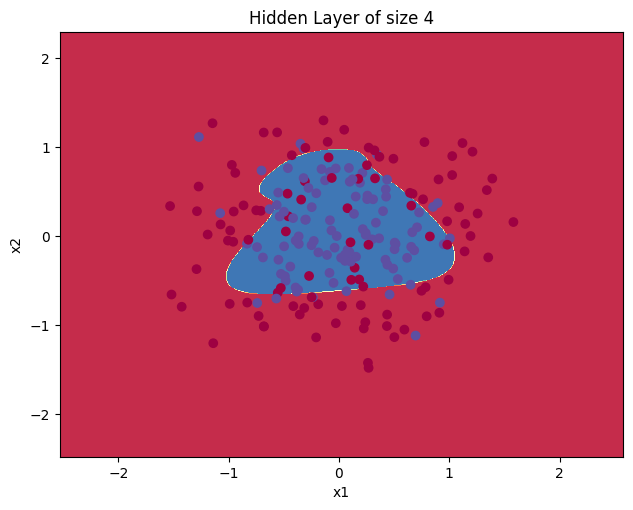

[[77 23]
 [19 81]]


<Figure size 640x480 with 0 Axes>

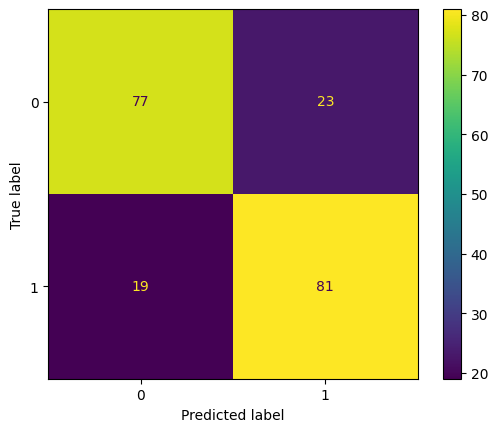

<ipython-input-17-e9c39f94cc8a>:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  accuracy = float((np.dot(Y,predictions.T) + np.dot(1 - Y, 1 - predictions.T)) / float(Y.size)*100)


Accuracy for 4 hidden units: 79.0 %
Cost after iteration 0: 0.693152
Cost after iteration 1000: 0.457227
Cost after iteration 2000: 0.454240
Cost after iteration 3000: 0.437348
Cost after iteration 4000: 0.430125
Cost after iteration 5000: 0.422732
Cost after iteration 6000: 0.418166
Cost after iteration 7000: 0.415304
Cost after iteration 8000: 0.413334
Cost after iteration 9000: 0.411871


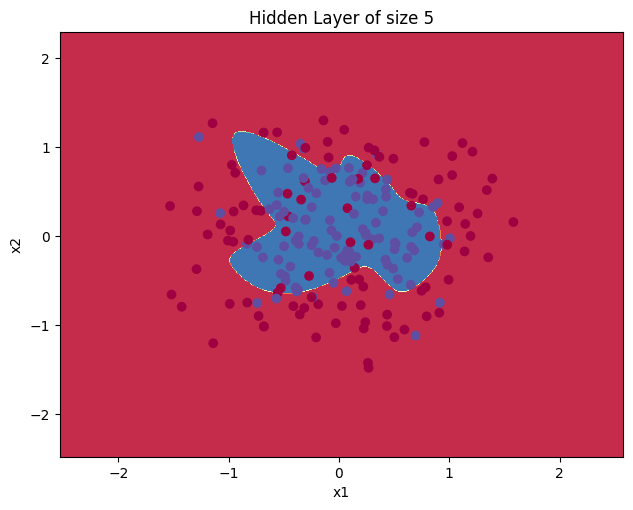

[[82 18]
 [22 78]]


<Figure size 640x480 with 0 Axes>

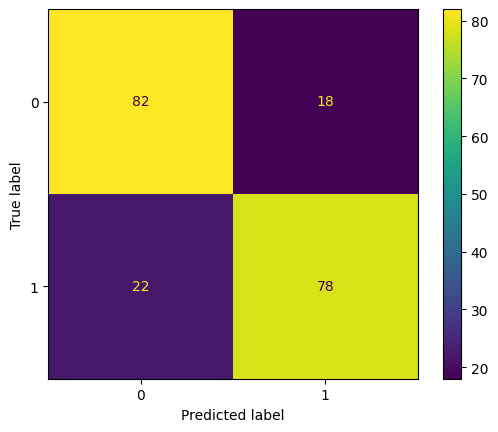

Accuracy for 5 hidden units: 80.0 %


<ipython-input-17-e9c39f94cc8a>:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  accuracy = float((np.dot(Y,predictions.T) + np.dot(1 - Y, 1 - predictions.T)) / float(Y.size)*100)


Cost after iteration 0: 0.693143
Cost after iteration 1000: 0.491467
Cost after iteration 2000: 0.434849
Cost after iteration 3000: 0.416514
Cost after iteration 4000: 0.413514
Cost after iteration 5000: 0.401901
Cost after iteration 6000: 0.393959
Cost after iteration 7000: 0.388732
Cost after iteration 8000: 0.385583
Cost after iteration 9000: 0.383384


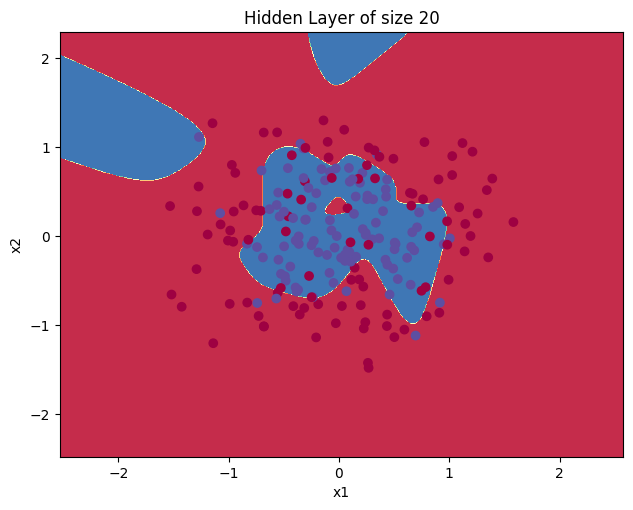

[[81 19]
 [14 86]]


<Figure size 640x480 with 0 Axes>

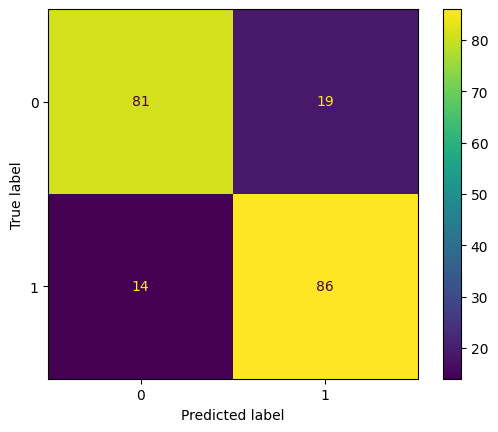

Accuracy for 20 hidden units: 83.5 %


<ipython-input-17-e9c39f94cc8a>:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  accuracy = float((np.dot(Y,predictions.T) + np.dot(1 - Y, 1 - predictions.T)) / float(Y.size)*100)


Cost after iteration 0: 0.693143
Cost after iteration 1000: 0.586604
Cost after iteration 2000: 0.452519
Cost after iteration 3000: 0.444510
Cost after iteration 4000: 0.440731
Cost after iteration 5000: 0.437772
Cost after iteration 6000: 0.429899
Cost after iteration 7000: 0.421280
Cost after iteration 8000: 0.400977
Cost after iteration 9000: 0.390172


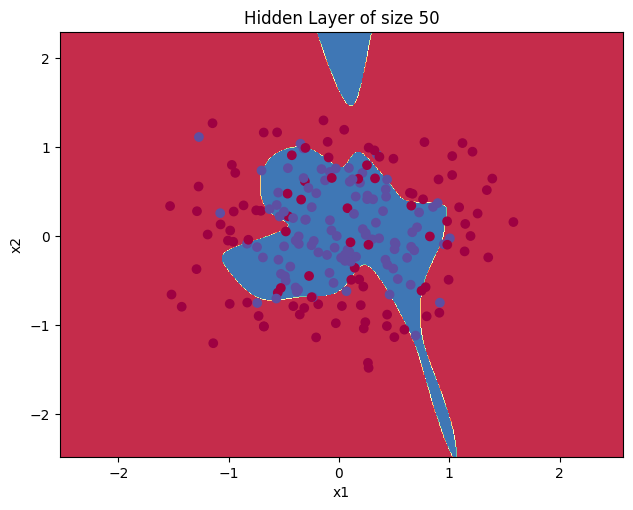

[[81 19]
 [14 86]]


<Figure size 640x480 with 0 Axes>

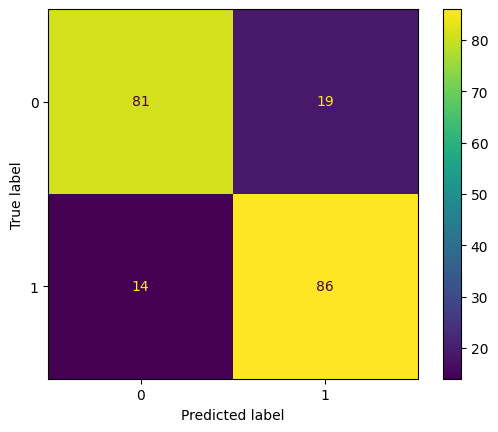

Accuracy for 50 hidden units: 83.5 %
Dataset: noisy_moons
(200,)


<ipython-input-17-e9c39f94cc8a>:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  accuracy = float((np.dot(Y,predictions.T) + np.dot(1 - Y, 1 - predictions.T)) / float(Y.size)*100)


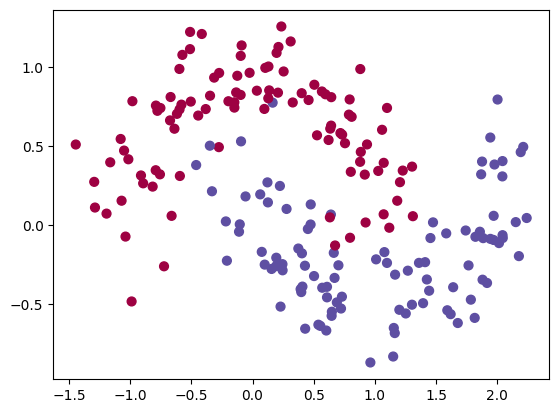

Cost after iteration 0: 0.693144
Cost after iteration 1000: 0.305191
Cost after iteration 2000: 0.305197
Cost after iteration 3000: 0.305197
Cost after iteration 4000: 0.305197
Cost after iteration 5000: 0.305197
Cost after iteration 6000: 0.305197
Cost after iteration 7000: 0.305197
Cost after iteration 8000: 0.305197
Cost after iteration 9000: 0.305197


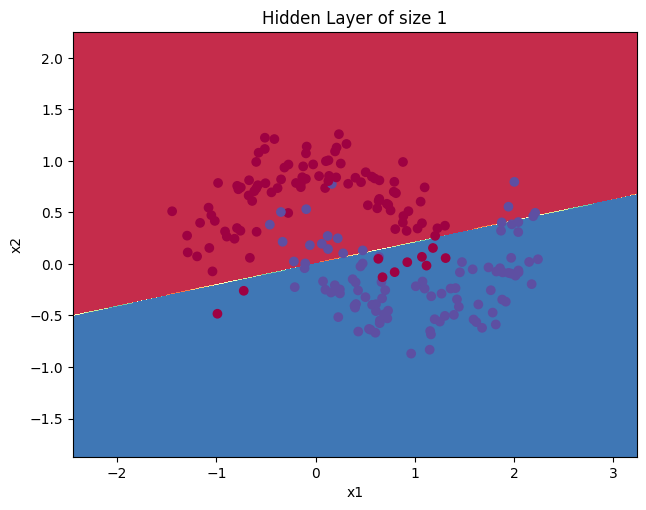

[[90 10]
 [19 81]]


<Figure size 640x480 with 0 Axes>

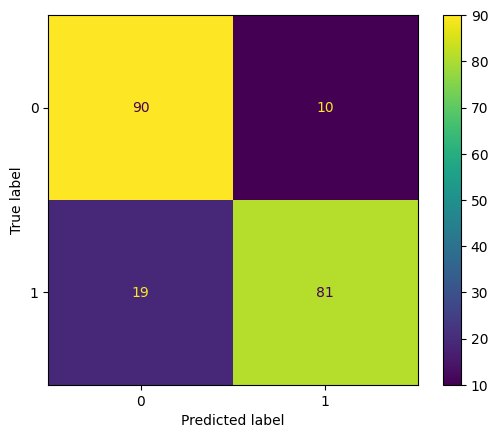

Accuracy for 1 hidden units: 85.5 %
Cost after iteration 0: 0.693171


<ipython-input-17-e9c39f94cc8a>:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  accuracy = float((np.dot(Y,predictions.T) + np.dot(1 - Y, 1 - predictions.T)) / float(Y.size)*100)


Cost after iteration 1000: 0.275740
Cost after iteration 2000: 0.271732
Cost after iteration 3000: 0.269374
Cost after iteration 4000: 0.267909
Cost after iteration 5000: 0.266919
Cost after iteration 6000: 0.266193
Cost after iteration 7000: 0.265628
Cost after iteration 8000: 0.265167
Cost after iteration 9000: 0.264780


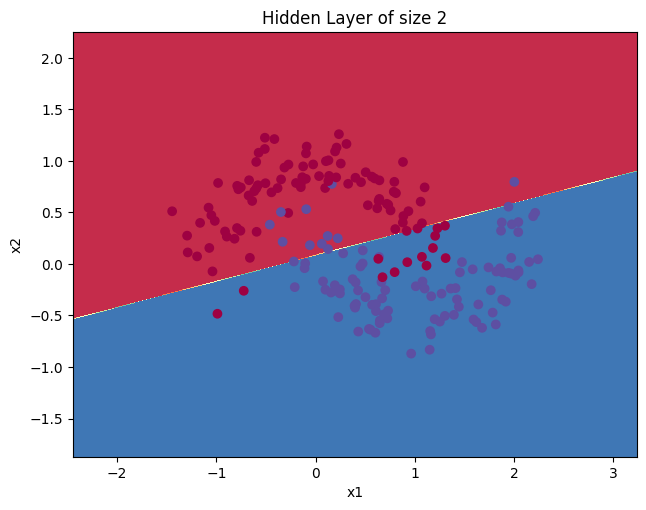

[[87 13]
 [11 89]]


<Figure size 640x480 with 0 Axes>

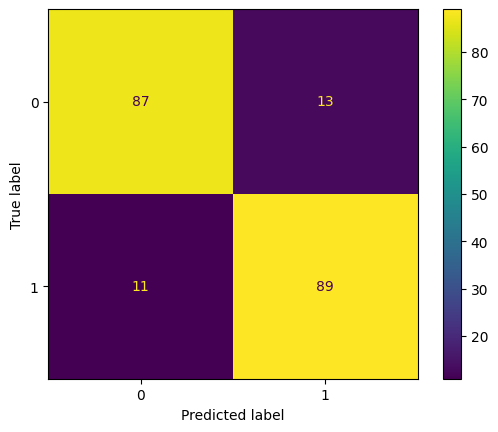

Accuracy for 2 hidden units: 88.0 %


<ipython-input-17-e9c39f94cc8a>:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  accuracy = float((np.dot(Y,predictions.T) + np.dot(1 - Y, 1 - predictions.T)) / float(Y.size)*100)


Cost after iteration 0: 0.693174
Cost after iteration 1000: 0.088027
Cost after iteration 2000: 0.071646
Cost after iteration 3000: 0.068258
Cost after iteration 4000: 0.066539
Cost after iteration 5000: 0.069861
Cost after iteration 6000: 0.071219
Cost after iteration 7000: 0.071815
Cost after iteration 8000: 0.072073
Cost after iteration 9000: 0.072182


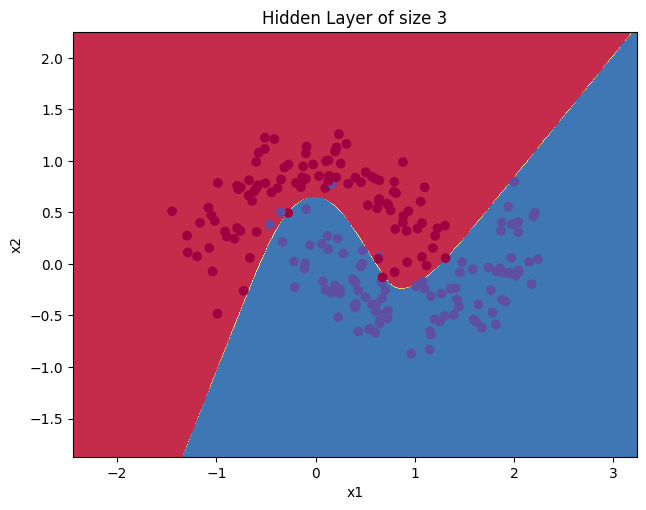

[[98  2]
 [ 4 96]]


<Figure size 640x480 with 0 Axes>

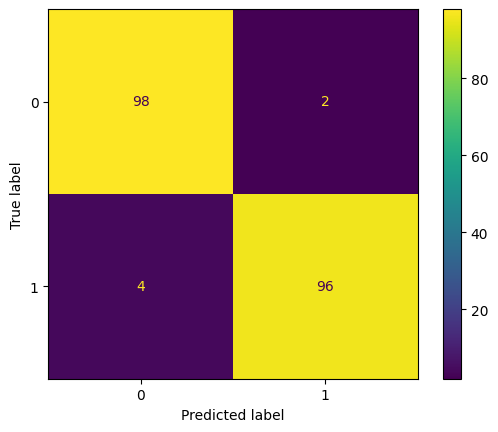

<ipython-input-17-e9c39f94cc8a>:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  accuracy = float((np.dot(Y,predictions.T) + np.dot(1 - Y, 1 - predictions.T)) / float(Y.size)*100)


Accuracy for 3 hidden units: 97.0 %
Cost after iteration 0: 0.693158
Cost after iteration 1000: 0.152031
Cost after iteration 2000: 0.070345
Cost after iteration 3000: 0.062862
Cost after iteration 4000: 0.059163
Cost after iteration 5000: 0.062127
Cost after iteration 6000: 0.060071
Cost after iteration 7000: 0.057960
Cost after iteration 8000: 0.056861
Cost after iteration 9000: 0.056176


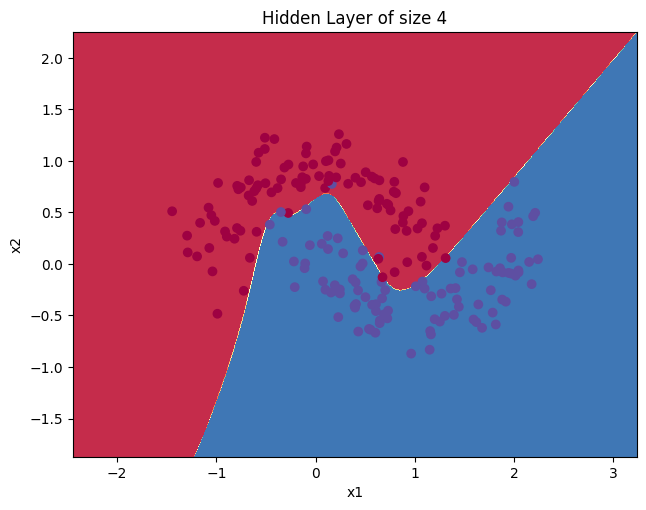

[[98  2]
 [ 3 97]]


<Figure size 640x480 with 0 Axes>

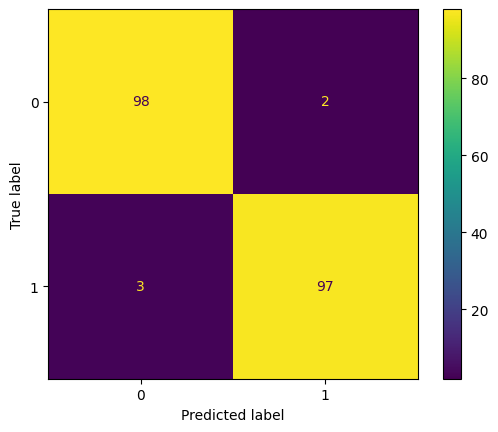

<ipython-input-17-e9c39f94cc8a>:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  accuracy = float((np.dot(Y,predictions.T) + np.dot(1 - Y, 1 - predictions.T)) / float(Y.size)*100)


Accuracy for 4 hidden units: 97.5 %
Cost after iteration 0: 0.693143
Cost after iteration 1000: 0.103078
Cost after iteration 2000: 0.070855
Cost after iteration 3000: 0.059242
Cost after iteration 4000: 0.054258
Cost after iteration 5000: 0.050205
Cost after iteration 6000: 0.044205
Cost after iteration 7000: 0.042379
Cost after iteration 8000: 0.040624
Cost after iteration 9000: 0.039567


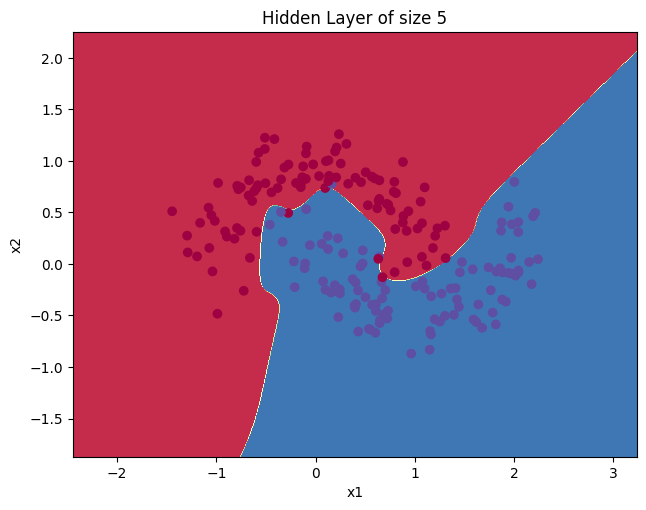

[[97  3]
 [ 1 99]]


<Figure size 640x480 with 0 Axes>

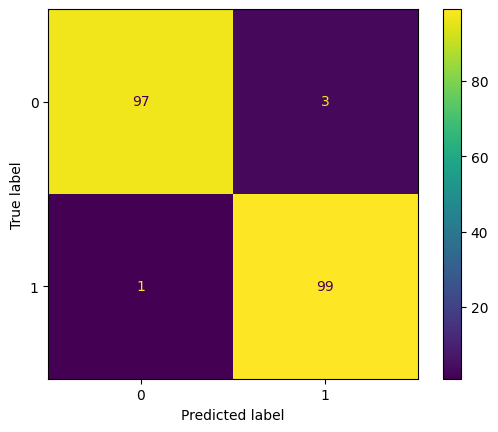

Accuracy for 5 hidden units: 98.0 %
Cost after iteration 0: 0.693324


<ipython-input-17-e9c39f94cc8a>:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  accuracy = float((np.dot(Y,predictions.T) + np.dot(1 - Y, 1 - predictions.T)) / float(Y.size)*100)


Cost after iteration 1000: 0.287285
Cost after iteration 2000: 0.113515
Cost after iteration 3000: 0.085007
Cost after iteration 4000: 0.082192
Cost after iteration 5000: 0.076828
Cost after iteration 6000: 0.067530
Cost after iteration 7000: 0.058489
Cost after iteration 8000: 0.050494
Cost after iteration 9000: 0.045238


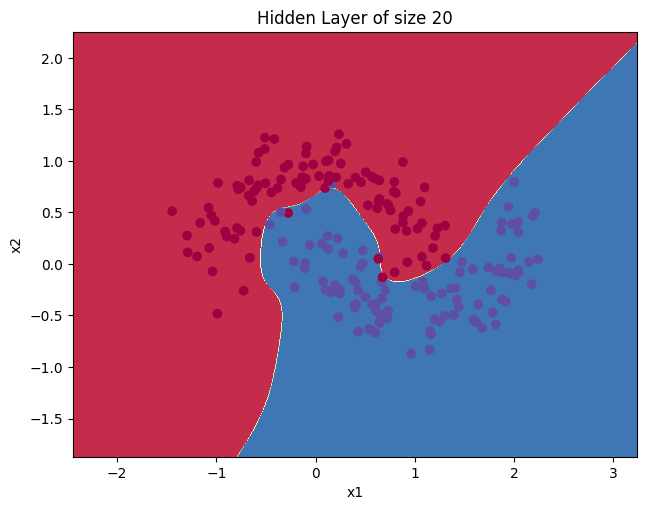

[[97  3]
 [ 1 99]]


<Figure size 640x480 with 0 Axes>

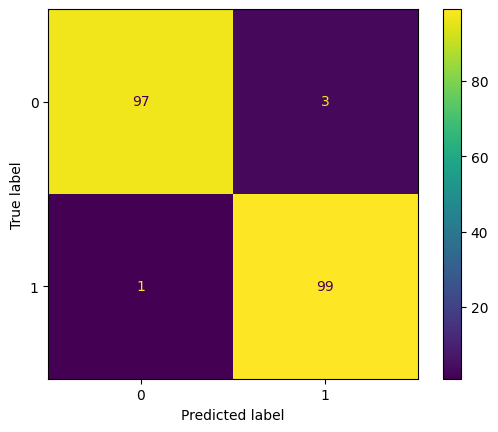

Accuracy for 20 hidden units: 98.0 %
Cost after iteration 0: 0.692929


<ipython-input-17-e9c39f94cc8a>:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  accuracy = float((np.dot(Y,predictions.T) + np.dot(1 - Y, 1 - predictions.T)) / float(Y.size)*100)


Cost after iteration 1000: 0.098330
Cost after iteration 2000: 0.089996
Cost after iteration 3000: 0.092981
Cost after iteration 4000: 0.088059
Cost after iteration 5000: 0.080095
Cost after iteration 6000: 0.085010
Cost after iteration 7000: 0.074885
Cost after iteration 8000: 0.072269
Cost after iteration 9000: 0.070349


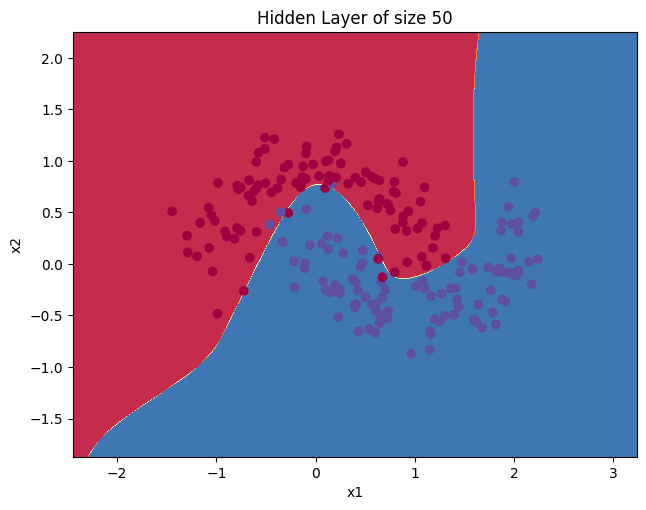

[[96  4]
 [ 3 97]]


<Figure size 640x480 with 0 Axes>

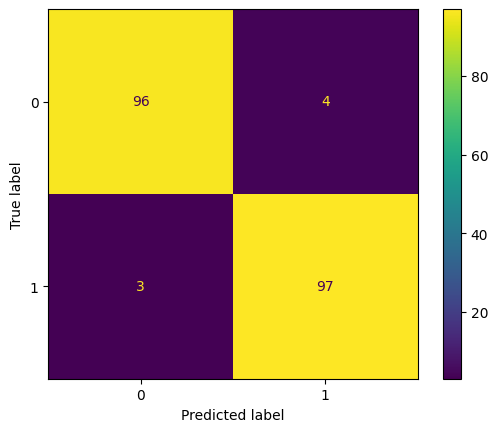

Accuracy for 50 hidden units: 96.5 %
Dataset: blobs
(200,)


<ipython-input-17-e9c39f94cc8a>:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  accuracy = float((np.dot(Y,predictions.T) + np.dot(1 - Y, 1 - predictions.T)) / float(Y.size)*100)


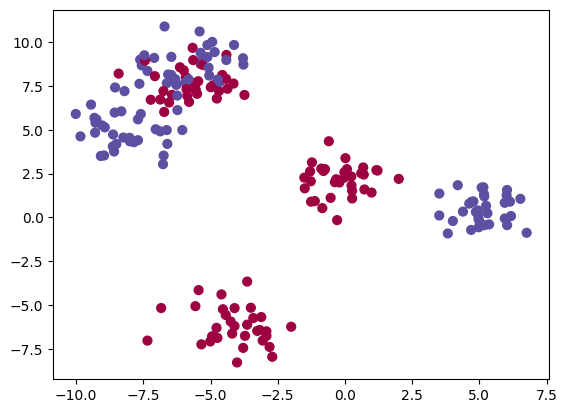

Cost after iteration 0: 0.693142
Cost after iteration 1000: 0.557157
Cost after iteration 2000: 0.556635
Cost after iteration 3000: 0.556376
Cost after iteration 4000: 0.556184
Cost after iteration 5000: 0.556018
Cost after iteration 6000: 0.555866
Cost after iteration 7000: 0.555723
Cost after iteration 8000: 0.555587
Cost after iteration 9000: 0.555458


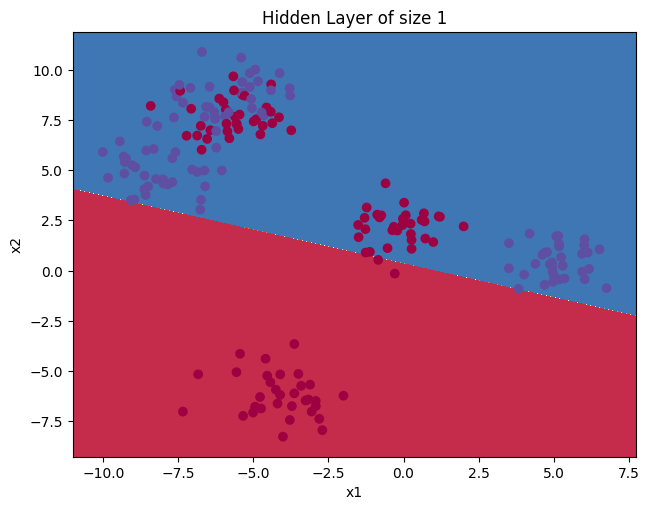

[[35 65]
 [ 1 99]]


<Figure size 640x480 with 0 Axes>

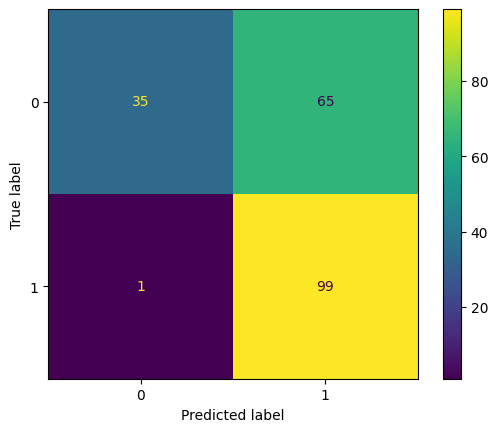

Accuracy for 1 hidden units: 67.0 %


<ipython-input-17-e9c39f94cc8a>:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  accuracy = float((np.dot(Y,predictions.T) + np.dot(1 - Y, 1 - predictions.T)) / float(Y.size)*100)


Cost after iteration 0: 0.693106
Cost after iteration 1000: 0.557357
Cost after iteration 2000: 0.556793
Cost after iteration 3000: 0.556534
Cost after iteration 4000: 0.556350
Cost after iteration 5000: 0.556195
Cost after iteration 6000: 0.556052
Cost after iteration 7000: 0.555917
Cost after iteration 8000: 0.555785
Cost after iteration 9000: 0.555657


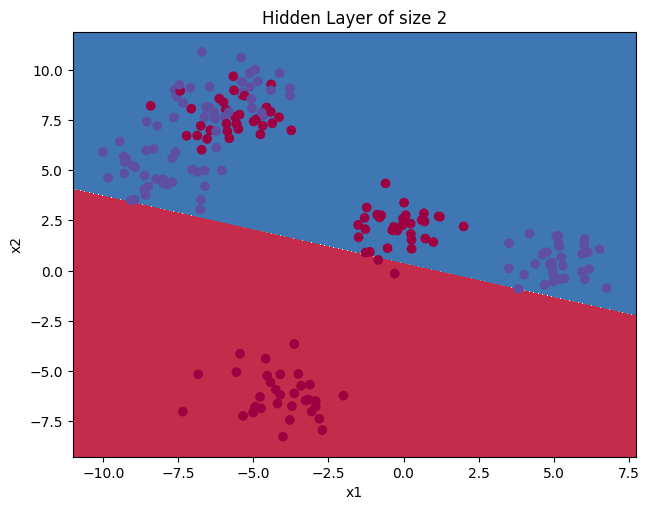

[[35 65]
 [ 1 99]]


<Figure size 640x480 with 0 Axes>

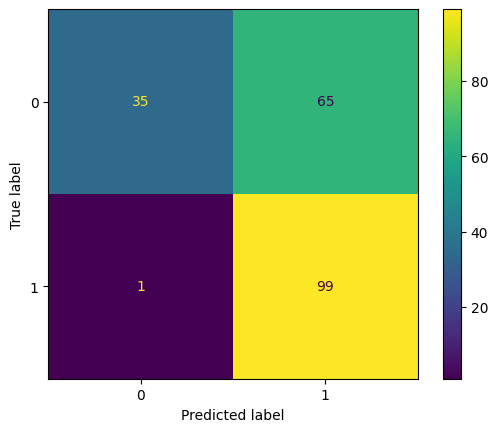

<ipython-input-17-e9c39f94cc8a>:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  accuracy = float((np.dot(Y,predictions.T) + np.dot(1 - Y, 1 - predictions.T)) / float(Y.size)*100)


Accuracy for 2 hidden units: 67.0 %
Cost after iteration 0: 0.693052
Cost after iteration 1000: 0.323507
Cost after iteration 2000: 0.323243
Cost after iteration 3000: 0.322942
Cost after iteration 4000: 0.322716
Cost after iteration 5000: 0.322808
Cost after iteration 6000: 0.323036
Cost after iteration 7000: 0.322746
Cost after iteration 8000: 0.322739
Cost after iteration 9000: 0.322700


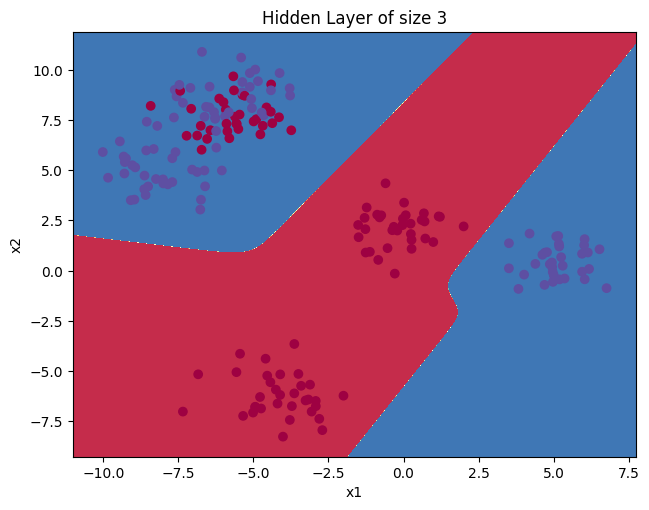

[[ 66  34]
 [  0 100]]


<Figure size 640x480 with 0 Axes>

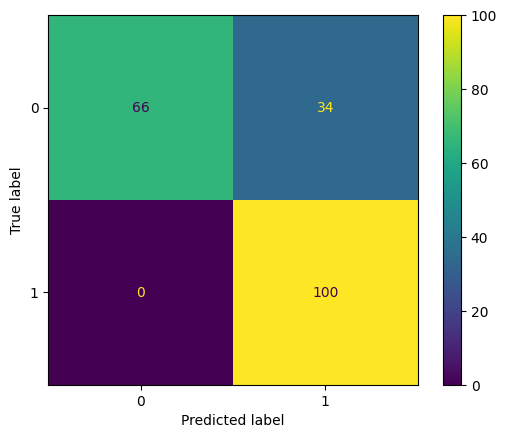

Accuracy for 3 hidden units: 83.0 %


<ipython-input-17-e9c39f94cc8a>:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  accuracy = float((np.dot(Y,predictions.T) + np.dot(1 - Y, 1 - predictions.T)) / float(Y.size)*100)


Cost after iteration 0: 0.693080
Cost after iteration 1000: 0.323760
Cost after iteration 2000: 0.323148
Cost after iteration 3000: 0.322858
Cost after iteration 4000: 0.322773
Cost after iteration 5000: 0.322738
Cost after iteration 6000: 0.322684
Cost after iteration 7000: 0.322697
Cost after iteration 8000: 0.322675
Cost after iteration 9000: 0.322662


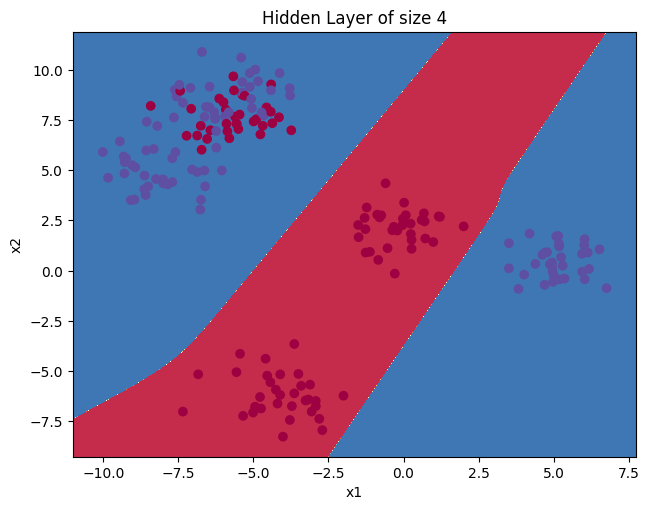

[[ 66  34]
 [  0 100]]


<Figure size 640x480 with 0 Axes>

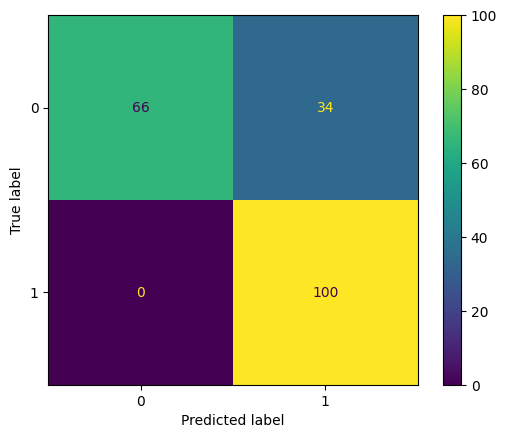

<ipython-input-17-e9c39f94cc8a>:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  accuracy = float((np.dot(Y,predictions.T) + np.dot(1 - Y, 1 - predictions.T)) / float(Y.size)*100)


Accuracy for 4 hidden units: 83.0 %
Cost after iteration 0: 0.693478
Cost after iteration 1000: 0.238254
Cost after iteration 2000: 0.236005
Cost after iteration 3000: 0.234595
Cost after iteration 4000: 0.234435
Cost after iteration 5000: 0.233721
Cost after iteration 6000: 0.233813
Cost after iteration 7000: 0.233619
Cost after iteration 8000: 0.233471
Cost after iteration 9000: 0.233367


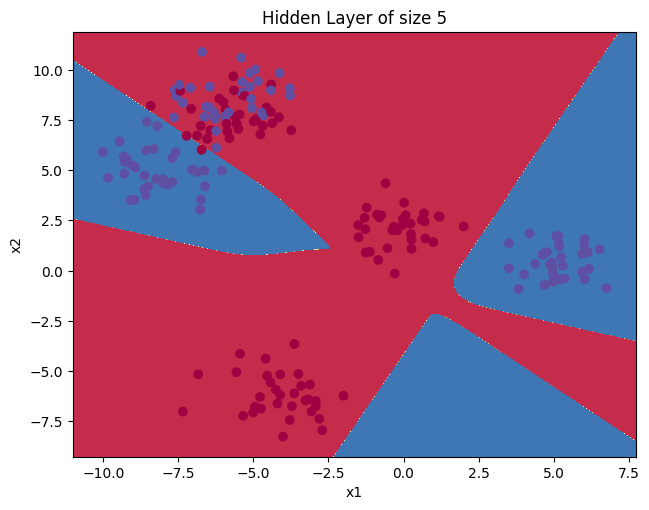

[[99  1]
 [33 67]]


<Figure size 640x480 with 0 Axes>

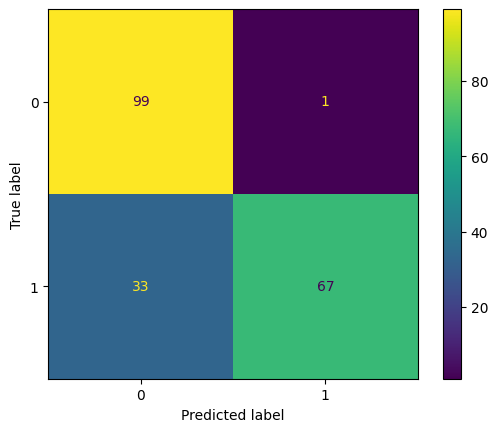

<ipython-input-17-e9c39f94cc8a>:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  accuracy = float((np.dot(Y,predictions.T) + np.dot(1 - Y, 1 - predictions.T)) / float(Y.size)*100)


Accuracy for 5 hidden units: 83.0 %
Cost after iteration 0: 0.692967
Cost after iteration 1000: 0.226904
Cost after iteration 2000: 0.228493
Cost after iteration 3000: 0.252155
Cost after iteration 4000: 0.227142
Cost after iteration 5000: 0.208352
Cost after iteration 6000: 0.205160
Cost after iteration 7000: 0.215576
Cost after iteration 8000: 0.197447
Cost after iteration 9000: 0.191841


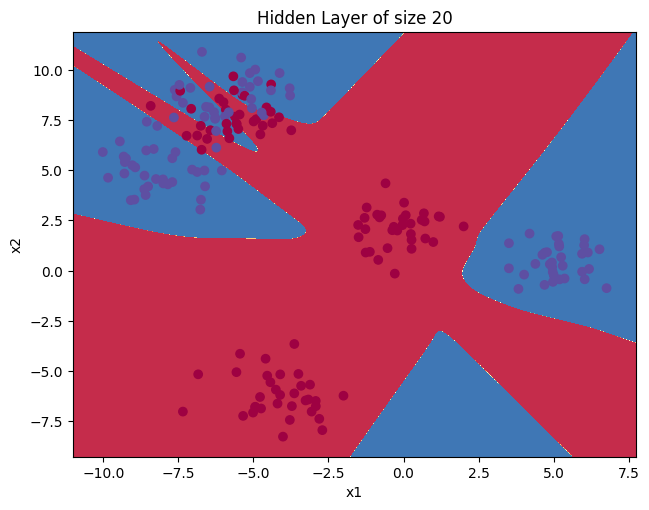

[[87 13]
 [ 7 93]]


<Figure size 640x480 with 0 Axes>

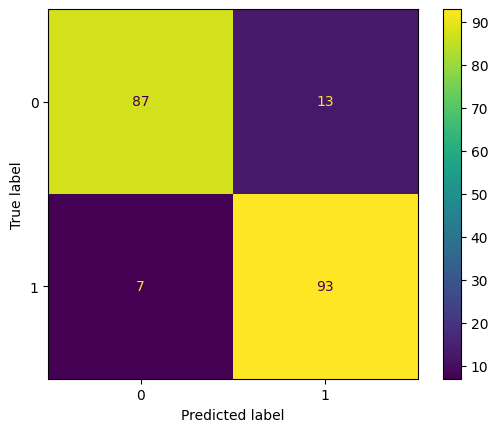

<ipython-input-17-e9c39f94cc8a>:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  accuracy = float((np.dot(Y,predictions.T) + np.dot(1 - Y, 1 - predictions.T)) / float(Y.size)*100)


Accuracy for 20 hidden units: 90.0 %
Cost after iteration 0: 0.692765
Cost after iteration 1000: 0.243185
Cost after iteration 2000: 0.238298
Cost after iteration 3000: 0.234275
Cost after iteration 4000: 0.226367
Cost after iteration 5000: 0.229886
Cost after iteration 6000: 0.228549
Cost after iteration 7000: 0.226979
Cost after iteration 8000: 0.225005
Cost after iteration 9000: 0.220212


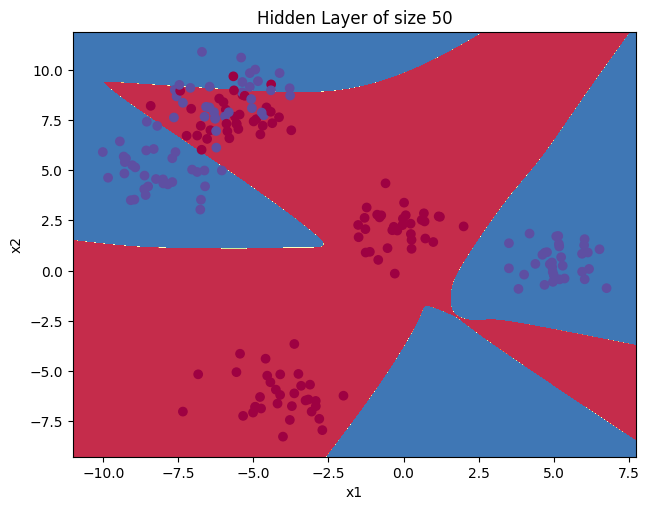

[[98  2]
 [21 79]]


<Figure size 640x480 with 0 Axes>

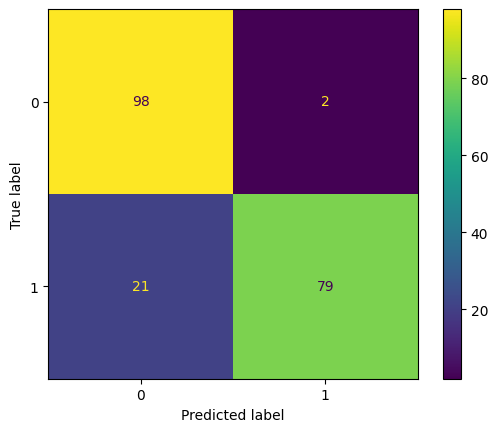

Accuracy for 50 hidden units: 88.5 %


<ipython-input-17-e9c39f94cc8a>:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  accuracy = float((np.dot(Y,predictions.T) + np.dot(1 - Y, 1 - predictions.T)) / float(Y.size)*100)


In [ ]:
#   CAMBIAR DE Datasets y REPETIR TODO EL CICLO

# 1. Cargamos datasets extra (círculos ruidosos, lunas, blobs)
noisy_circles, noisy_moons, blobs = load_extra_datasets()

datasets = {"noisy_circles": noisy_circles,
            "noisy_moons": noisy_moons,
            "blobs": blobs}

# Lista de datasets y tamaños de capa oculta a probar
list_data = list(datasets.keys())
hidden_layer_sizes = [1, 2, 3, 4, 5, 20, 50]

# 2. Iteramos sobre cada dataset
for dataset in list_data:

    print(f'Dataset: {dataset}')
    X, Y = datasets[dataset]
    print(Y.shape)

    # Reorganizamos X e Y para que tengan el mismo formato que el planar
    X, Y = X.T, Y.reshape(1, Y.shape[0])

    # Si el dataset es "blobs", lo hacemos binario (clases pares = 0, impares = 1)
    if dataset == "blobs":
        Y = Y % 2

    # Visualizamos el dataset
    plt.figure()
    plt.scatter(X[0, :], X[1, :], c=Y, s=40, cmap=plt.cm.Spectral)
    plt.show()
    plt.close()

    # 3. Para cada tamaño de capa oculta entrenamos una red neuronal
    for i, n_h in enumerate(hidden_layer_sizes):

        plt.figure(figsize=(16, 32))
        plt.subplot(5, 2, i+1)
        plt.title('Hidden Layer of size %d' % n_h)

        # Entrenamos el modelo
        parameters = nn_model(X, Y, n_h, num_iterations=10000, print_cost=True)

        # Dibujamos la frontera de decisión
        plot_decision_boundary(lambda x: predict(parameters, x.T), X, Y)
        plt.show()
        plt.close()

        # 4. Evaluación del modelo
        predictions = predict(parameters, X)

        # Mostramos matriz de confusión
        matriz_confusion(Y.flatten(), predictions.flatten())

        # Calculamos accuracy
        accuracy = float((np.dot(Y, predictions.T) + np.dot(1 - Y, 1 - predictions.T)) / float(Y.size) * 100)
        print("Accuracy for {} hidden units: {} %".format(n_h, accuracy))
